# what is k-means 

* Definition (interview ready):
K-Means is an unsupervised learning algorithm that groups data into K clusters such that data points in the same cluster are more similar to each other than to those in other clusters.

flowchart TD

                 +--------------------+
                 |       START        |
                 +---------+----------+
                           |
                           v
                 +--------------------+
                 | Choose K clusters  |
                 +---------+----------+
                           |
                           v
          +--------------------------------------------+
          | Randomly pick K data points as  centroids  |
          +-----------------+--------------------------+
                            |
                            v
         +-------------------------------------+
         | Assign each point to nearest        |
         | centroid (Euclidean distance)       |
         +------------------+------------------+
                            |
                            v
         +-------------------------------------+
         | Update centroids: mean of points    |
         | in each cluster                     |
         +------------------+------------------+
                            |
                            v
                  +-----------------------+
                  | Centroids changed?    |
                  +-----------+-----------+
                              | 
                +-------------+--------------+
                |                            |
               YES                          NO
                |                            |
                v                            v
  +------------------------------+     +----------------------+
  | Repeat assignment + update   |     |       FINISH         |
  | (Go back to step above)      |     |  Final clusters set  |
  +------------------------------+     +----------------------+

# 📉 Objective Function (Important for Interviews)
* K-Means minimizes:
* J=∑(distance between point and centroid) ^ 2
 
# This is called Within Cluster Sum of Squares (WCSS)
* WCSS is the sum of squared distances between each data point and the centroid of the cluster it belongs to.
* It measures how compact (tight) the clusters are.

* “WCSS stands for Within-Cluster Sum of Squares. It is the total squared distance between data points and their cluster centroid. It measures cluster compactness and is used in the Elbow Method to choose the optimal number of clusters.”

# 📊 How to Choose K? → Elbow Method
* Plot:
* X-axis → K
* Y-axis → WCSS
# Choose K where graph bends like an “elbow”

# ⚠️ Limitations (VERY IMPORTANT)
* Interviewers LOVE this part.
* ❌ Need to choose K manually
* ❌ Sensitive to initial centroids
* ❌ Doesn’t work well with:

1. Non-spherical data
2. Different density clusters
* ❌ Affected by outliers

# ✅ Advantages
1. ✔ Simple & fast
2. ✔ Works well for large datasets
3. ✔ Easy to implement

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import pandas as pd

data = {
    "cgpa": [
        5.13,5.9,8.36,8.27,5.45,5.88,8.41,8.8,5.79,8.09,
        4.6,6.1,8.16,5.0,5.71,8.31,5.5,7.87,6.05,5.84,
        7.47,4.86,7.78,4.78,4.96,7.93,4.86,9.18,8.04,5.43,
        8.86,6.01,8.83,5.32,7.77,8.0,8.56,5.91,5.44,5.57,
        5.34,8.43,8.02,5.31,8.96,8.78,8.14,6.4,8.45,5.67,
        5.14,4.95,8.79,8.12,8.81,6.05,5.85,8.88,5.87,9.07,
        6.02,8.34,8.65,8.92,5.21,8.75,8.53,4.91,5.77,8.29,
        6.06,8.71,7.93,5.28,5.55,8.86,5.81,9.3,5.15,8.72,
        8.14,9.01,5.47,4.9,8.97,4.89,9.0,5.74,8.76,5.8,
        8.78,9.23,8.2,5.05,8.67,8.18,9.03,8.61,4.98,9.13,
        5.88,5.01,4.95,8.91,4.96,4.85,7.99,4.76,8.98,9.03,
        8.08,8.86,5.91,5.67,8.26,8.89,8.25,5.74,8.97,4.98,
        4.78,5.69,8.4,8.72,7.84,5.2,8.08,6.05,5.05,8.25,
        8.3,6.14,5.01,4.77,5.74,8.93,5.94,4.68,7.9,7.97,
        8.21,4.81,5.86,5.03,4.98,8.58,5.32,8.94,6.38,4.86,
        8.6,4.89,8.77,8.81,4.88,8.23,6.61,8.54,6.04,8.35,
        5.01,8.97,6.24,8.33,8.91,4.67,6.1,5.15,4.97,8.68,
        9.06,5.8,8.9,4.87,5.2,8.46,8.94,5.87,4.99,8.91,
        8.91,5.97,6.17,6.01,7.89,4.79,7.91,8.23,8.95,6.33,
        8.4,8.44,4.76,4.78,8.79,4.68,8.57,5.85,6.23,8.82
    ],
    "iq": [
        88,113,93,97,110,109,98,115,110,94,
        86,110,97,88,108,95,111,91,111,113,
        98,86,92,87,88,98,87,119,94,106,
        117,112,118,106,96,96,118,108,84,113,
        85,96,93,86,116,116,94,108,119,109,
        83,86,116,96,115,108,111,115,109,117,
        104,96,95,118,87,113,93,85,111,95,
        109,116,94,83,109,118,112,117,88,92,
        91,121,111,85,116,88,117,109,117,108,
        117,114,92,86,95,94,118,95,91,118,
        110,86,88,119,89,86,92,90,118,118,
        94,117,109,111,91,118,95,108,117,87,
        87,109,93,119,97,85,98,109,87,96,
        93,111,83,86,112,118,109,87,100,96,
        94,85,111,87,87,118,88,117,107,88,
        117,85,117,116,86,95,111,118,110,93,
        86,119,108,92,117,86,109,85,88,119,
        120,110,117,88,89,98,115,108,88,115,
        117,108,110,110,107,96,88,93,91,111,
        93,94,89,85,96,89,118,112,108,117
    ]
}

ds = pd.DataFrame(data)
ds.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


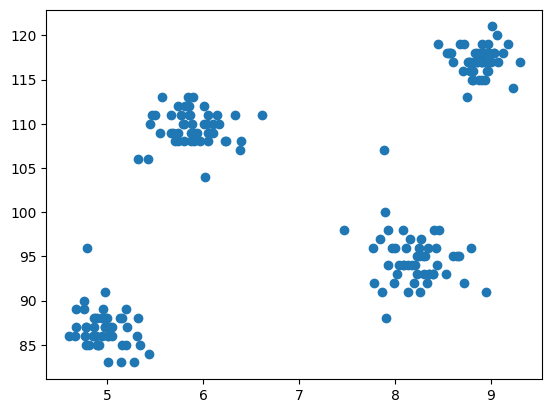

In [3]:
plt.scatter(ds["cgpa"],ds['iq'])
plt.show()

In [4]:
from sklearn.cluster import KMeans

In [5]:
wcss = []
for i in range(1,13):
    km = KMeans(n_clusters = i)
    km.fit_predict(ds)
    wcss.append(km.inertia_)

In [9]:
# this is used for showing the centroids 
centroids = km.cluster_centers_
print(centroids)

[[  8.89037037 116.2962963 ]
 [  4.89        89.5       ]
 [  6.208      106.        ]
 [  8.0796      96.4       ]
 [  4.94421053  85.57894737]
 [  5.91611111 110.55555556]
 [  8.2376      92.8       ]
 [  6.18375    112.5       ]
 [  8.84904762 118.52380952]
 [  5.11190476  87.57142857]
 [  5.2175      83.25      ]
 [  5.92285714 108.52380952]]


In [33]:
wcss

[29825.658288,
 4189.533525999999,
 2384.5800769999996,
 705.0751367739095,
 637.5913342272498,
 481.34716720887525,
 383.9095016142387,
 258.0153189674223,
 274.3295251037734,
 217.86465676937442,
 190.32178659326294,
 162.01855309764082]

# drow a graph 

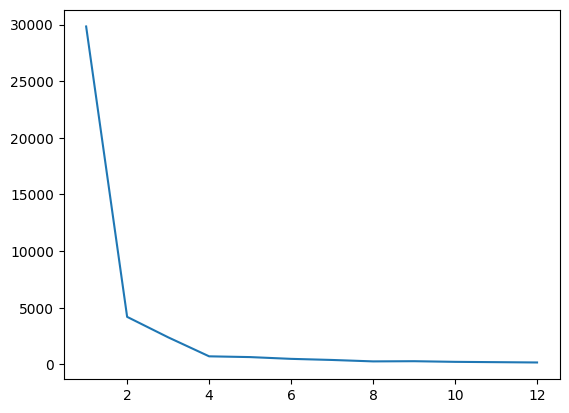

In [34]:
plt.plot(range(1,13), wcss)

In [40]:
X = ds.iloc[:,:].values
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)
print(y_means)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
[3 1 0 0 1 1 0 2 1 0 3 1 0 3 1 0 1 0 1 1 0 3 0 3 3 0 3 2 0 1 2 1 2 1 0 0 2
 1 3 1 3 0 0 3 2 2 0 1 2 1 3 3 2 0 2 1 1 2 1 2 1 0 0 2 3 2 0 3 1 0 1 2 0 3
 1 2 1 2 3 0 0 2 1 3 2 3 2 1 2 1 2 2 0 3 0 0 2 0 3 2 1 3 3 2 3 3 0 3 2 2 0
 2 1 1 0 2 0 1 2 3 3 1 0 2 0 3 0 1 3 0 0 1 3 3 1 2 1 3 0 0 0 3 1 3 3 2 3 2
 1 3 2 3 2 2 3 0 1 2 1 0 3 2 1 0 2 3 1 3 3 2 2 1 2 3 3 0 2 1 3 2 2 1 1 1 1
 0 3 0 0 1 0 0 3 3 0 3 2 1 1 2]


In [42]:
X[y_means == 3,1]

array([88., 86., 88., 86., 87., 88., 87., 84., 85., 86., 83., 86., 87.,
       85., 83., 88., 85., 88., 86., 91., 86., 88., 89., 86., 90., 87.,
       87., 85., 87., 83., 86., 87., 85., 87., 87., 88., 88., 85., 86.,
       86., 86., 85., 88., 88., 89., 88., 88., 89., 85., 89.])

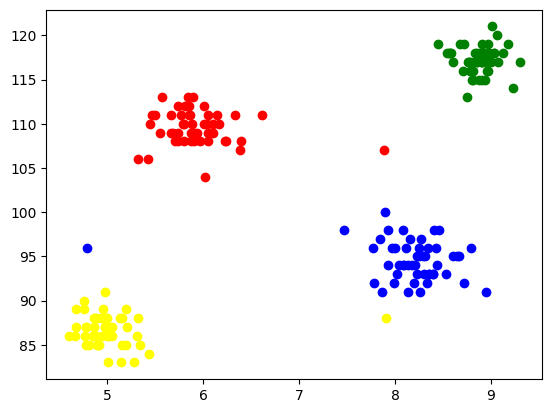

In [41]:

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='blue')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='red')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')

# for the 3d vusualization 

In [47]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)


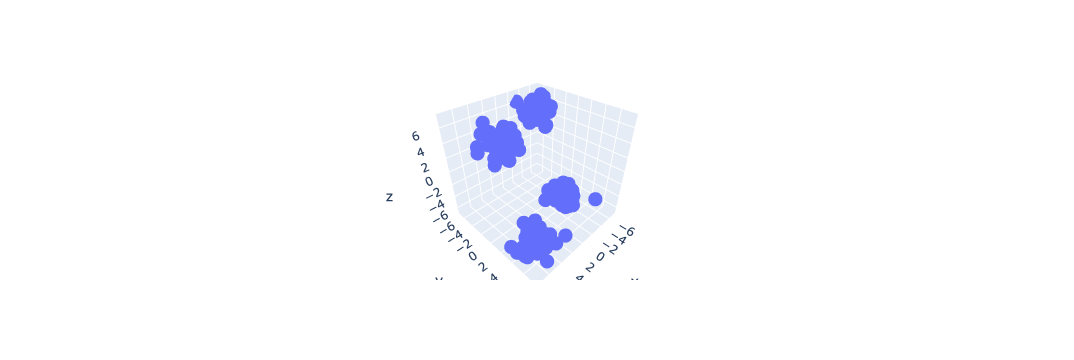

In [48]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()